# NUM model, 30-year spin-up on an A100: paper-style diagnostics

A 30-year global run of the Julia/CUDA port (fused kernel) on a RunPod A100, analysed with the
diagnostics of **Serra-Pompei et al. (2022), "Linking plankton size spectra and community
composition to carbon export and its efficiency", *Global Biogeochemical Cycles* 36, e2021GB007275**.
That study used NUM in the same MITgcm 2.8° transport matrices, started nitrogen from World Ocean
Atlas nitrate and ran 30 years, then analysed the last year (their Figs. 2, 6 and 8).

**Differences from the paper (read before comparing numbers):**
* Model version: NUMmodel v1.0 `setupNUMmodel` — 10 generalists + 10 diatoms (the paper: 14
  generalist protists, no diatoms), 2 passive + 3 active copepod groups × 6 stages (paper: 2 + 6
  populations × 5 stages), and **one** POM class (paper: 8 fecal-pellet + 8 deadfall classes with
  size-dependent sinking). Export here is the single POM class sinking at 19 m/day.
* Forcing: converted TMM `ironmops` matrices and the GCM's own temperature (see
  `NUMmodel/TMs/MITgcm_2.8deg/README_converted.md`), NUM's `parday` light.
* Definitions below follow upstream code (`getFunctions`, `calcCommunitySpectrum`) and the paper's
  text; where the paper's exact choice is not stated (e.g. the depth range of Fig. 2 biomass),
  the choice is stated in the cell.

So expect the same *patterns* and similar magnitudes, not identical maps.

In [1]:
import json, re, warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.io import loadmat
import h5py
warnings.filterwarnings("ignore", message="Mean of empty slice")
warnings.filterwarnings("ignore", message="invalid value encountered")
warnings.filterwarnings("ignore", message="divide by zero")

ROOT = (Path("..") if Path("../reference").exists() else Path(".")).resolve()
import os
RUN = Path(os.environ.get("NUM_SPINUP_FILE", ROOT / "reference" / "spinup_30yr.mat"))
with h5py.File(RUN, "r") as h:
    r = {k: np.array(h[k]) for k in h.keys() if isinstance(h[k], h5py.Dataset)}
# h5py reads Matlab-order arrays transposed
Umean = r["U_mean"].T; NPPy = r["NPP_year"].ravel(); Umon = r["U_month"].T; tmon = r["t_month"].ravel()
N_year, B_year, wall = r["N_year"].ravel(), r["B_year"].T, r["wall_year"].ravel()
ix, iy, iz = (r[k].ravel().astype(int) - 1 for k in ("ixBox", "iyBox", "izBox"))
vol, vel, years = r["vol"].ravel(), r["velocity"].ravel(), int(np.array(r["years"]).ravel()[0])
with h5py.File(RUN, "r") as h:   # group names: MAT.jl stores a string vector as a char matrix
    gnames = ["".join(chr(c) for c in col).strip() for col in np.array(h["group_names"]).T]
grid = loadmat(ROOT / "NUMmodel/TMs/MITgcm_2.8deg/grid.mat")
x, y, z, dz = grid["x"].ravel(), grid["y"].ravel(), grid["z"].ravel(), grid["dznom"].ravel()
nx, ny, nz = len(x), len(y), len(z)
classes = json.loads((ROOT / "reference/num_classes.json").read_text())
m = np.array([c["m"] for c in classes]); mLower = np.array([c["mLower"] for c in classes])
mDelta = np.array([c["mDelta"] for c in classes]); ctype = np.array([c["type"] for c in classes])
cgroup = np.array([c["group"] for c in classes])
nN = 3; B = Umean[:, nN:]
print(f"{years} years; boxes {Umean.shape[0]}; monthly snapshots {Umon.shape[2]}; groups {gnames}")
print(f"wall clock per model year: first {wall[0]:.1f} s, median of the rest {np.median(wall[1:]):.1f} s, total {wall.sum()/60:.1f} min")

def to_grid(v):
    G = np.full((nx, ny, nz), np.nan); G[ix, iy, iz] = v; return G
ocean = ~np.isnan(to_grid(np.ones(len(ix)))[:, :, 0])
def gmap(ax, field, title, norm=None, cmap="viridis", **kw):
    ax.set_facecolor("0.8")
    pc = ax.pcolormesh(x, y, field.T, norm=norm, cmap=cmap, shading="auto", **kw)
    ax.set_title(title, fontsize=10); ax.set_xticks([0, 90, 180, 270, 360]); ax.set_yticks([-60, -30, 0, 30, 60])
    return pc

30 years; boxes 52749; monthly snapshots 12; groups ['generalist', 'diatom', 'copepod_passive', 'copepod_active', 'pom']
wall clock per model year: first 18.1 s, median of the rest 6.0 s, total 3.3 min


## 1. Spin-up trajectory

Global nitrogen and total biomass of each group at the end of every model year. The paper notes
that 30 years is enough for the plankton compartments but not for the deep nutrient field, which
keeps drifting slowly.

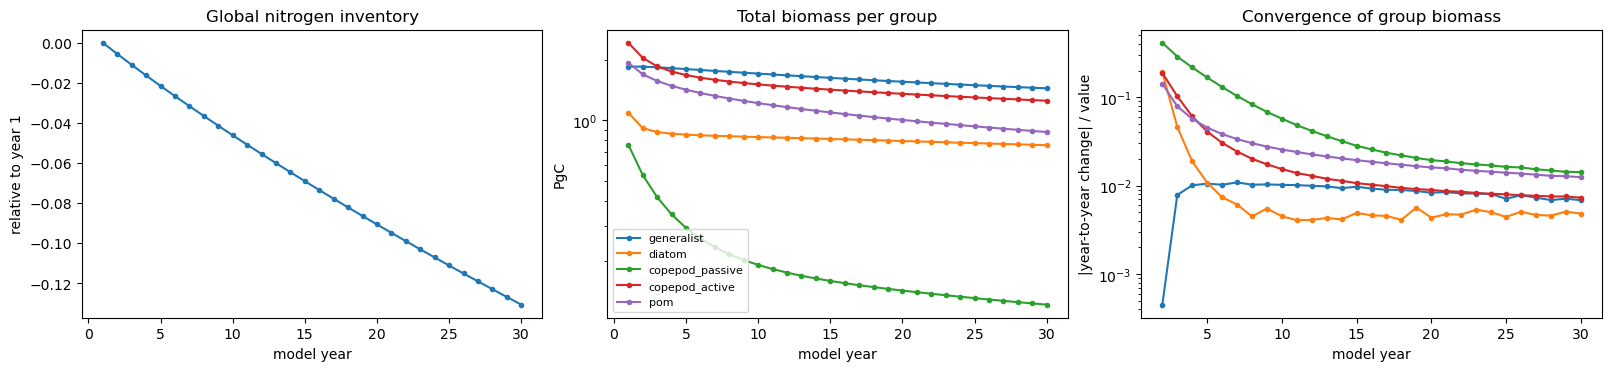

last-year relative change per group: {'generalist': np.float64(0.00685), 'diatom': np.float64(0.00484), 'copepod_passive': np.float64(0.01424), 'copepod_active': np.float64(0.00732), 'pom': np.float64(0.01248)}


In [2]:
yrs = np.arange(1, years + 1)
fig, ax = plt.subplots(1, 3, figsize=(16, 3.6), constrained_layout=True)
ax[0].plot(yrs, N_year / N_year[0] - 1, "o-", ms=3); ax[0].set(xlabel="model year", ylabel="relative to year 1", title="Global nitrogen inventory")
for k, nm in enumerate(gnames):
    ax[1].semilogy(yrs, B_year[:, k] / 1e15, "o-", ms=3, label=nm)
ax[1].set(xlabel="model year", ylabel="PgC", title="Total biomass per group"); ax[1].legend(fontsize=8)
rel = np.abs(np.diff(B_year, axis=0)) / B_year[1:]
for k, nm in enumerate(gnames):
    ax[2].semilogy(yrs[1:], rel[:, k], "o-", ms=3, label=nm)
ax[2].set(xlabel="model year", ylabel="|year-to-year change| / value", title="Convergence of group biomass")
plt.show()
if len(rel):
    print("last-year relative change per group:", dict(zip(gnames, np.round(rel[-1], 5))))

## 2. Biomass and size-spectrum exponent (cf. Serra-Pompei et al. 2022, Fig. 2)

(a) Protists = generalists + diatoms and (b) copepods, annual mean, integrated over the upper two
layers (0–120 m, the paper's export horizon; the paper does not state its depth range for Fig. 2).
(c) Exponent λ of the normalized community biomass spectrum B(m) ∝ m^λ, from the annual-mean
0–120 m community spectrum built as upstream `calcCommunitySpectrum.m` (each group's Sheldon
spectrum interpolated in log mass onto a common grid, POM excluded) and a least-squares fit in
log–log space. The paper finds λ between −1.3 (oligotrophic) and −0.7 (productive).

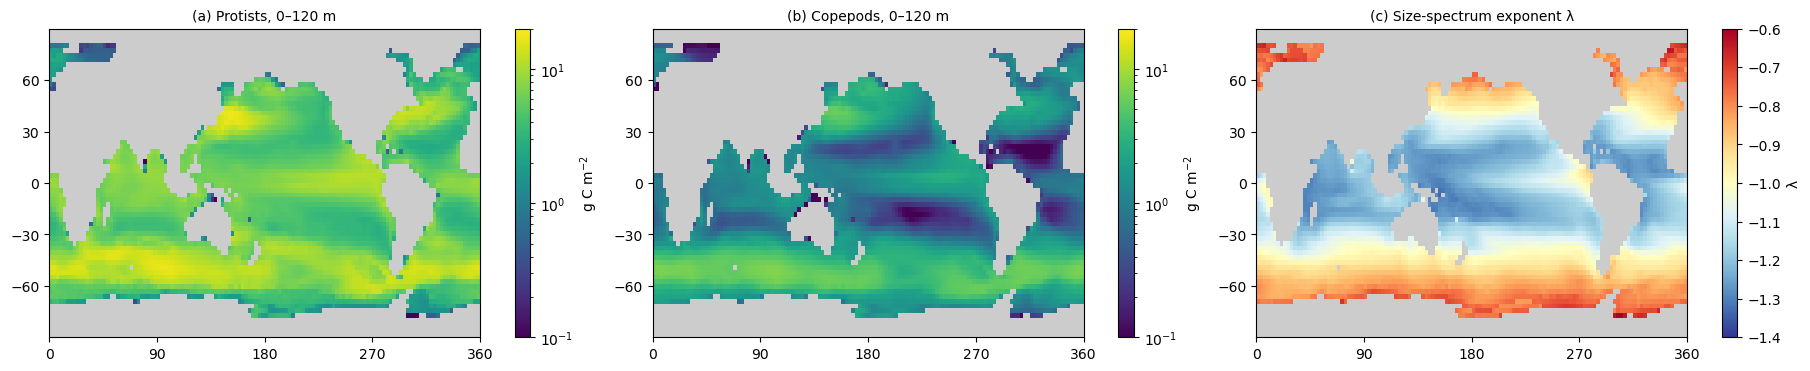

exponent range (5-95%): -1.27 to -0.76; median -1.06


In [3]:
up = iz < 2                                          # layers 1-2: 0-120 m
w = dz[iz]                                           # layer thickness per box
def integ(v, sel=up):                                # sum over selected layers of v*dz -> per column
    G = np.zeros((nx, ny)); np.add.at(G, (ix[sel], iy[sel]), (v * w)[sel]); return np.where(ocean, G, np.nan)
prot = np.isin(ctype, ["Generalists", "Diatoms"]); cope = np.isin(ctype, ["Passive copepods", "Active copepods"])
Bprot = integ(B[:, prot].sum(1)) / 1000; Bcop = integ(B[:, cope].sum(1)) / 1000        # g C / m^2

# community spectrum on the 0-120 m mean (thickness-weighted average of layers 1-2)
Bup = np.zeros((nx, ny, B.shape[1])); np.add.at(Bup, (ix[up], iy[up]), B[up] * w[up, None])
Bup = Bup / dz[:2].sum()
mc = np.logspace(np.log10(m.min()), np.log10(m[ctype != "POM"].max()), 100)
def community_spectrum(Bcols):                        # Bcols: (..., 51) -> (..., 100) normalized spectrum
    Bc = np.where(Bcols > 0, Bcols, 1e-100)
    BSh = np.zeros(Bc.shape[:-1] + (len(mc),))
    for gi in np.unique(cgroup):
        sel = cgroup == gi
        if ctype[sel][0] == "POM":
            continue
        logk = np.log(Bc[..., sel] / np.log((mLower[sel] + mDelta[sel]) / mLower[sel]))
        lm = np.log(m[sel]); inside = (np.log(mc) >= lm[0]) & (np.log(mc) <= lm[-1])
        # linear interpolation in log mass (np.interp along the last axis)
        vals = np.apply_along_axis(lambda v: np.interp(np.log(mc[inside]), lm, v), -1, logk)
        BSh[..., inside] += np.exp(vals)
    dff = np.diff(np.log(mc)); mU = np.exp(np.log(mc) + 0.5 * np.append(dff, dff[-1])); mL = np.exp(np.log(mc) - 0.5 * np.insert(dff, 0, dff[0]))
    return BSh / (mU - mL) * (mc[1] / mc[0])
spec = community_spectrum(Bup[ocean])
def fit_exponent(sp):
    # least squares in log-log over the populated part of the spectrum: mass points covered by
    # a group and above 1e-12 of the maximum (extinct groups carry upstream's 1e-100 floor)
    ok = sp > 1e-12 * sp.max()
    return np.polyfit(np.log(mc[ok]), np.log(sp[ok]), 1)[0] if ok.sum() > 10 else np.nan
lam = np.full((nx, ny), np.nan)
lam[ocean] = [fit_exponent(sp) for sp in spec]

fig, axs = plt.subplots(1, 3, figsize=(18, 3.6), constrained_layout=True)
fig.colorbar(gmap(axs[0], Bprot, "(a) Protists, 0–120 m", LogNorm(0.1, 20)), ax=axs[0], label="g C m$^{-2}$")
fig.colorbar(gmap(axs[1], Bcop, "(b) Copepods, 0–120 m", LogNorm(0.1, 20)), ax=axs[1], label="g C m$^{-2}$")
fig.colorbar(gmap(axs[2], lam, "(c) Size-spectrum exponent λ", None, "RdYlBu_r", vmin=-1.4, vmax=-0.6), ax=axs[2], label="λ")
plt.show()
print(f"exponent range (5-95%): {np.nanpercentile(lam, 5):.2f} to {np.nanpercentile(lam, 95):.2f}; median {np.nanmedian(lam):.2f}")

## 3. Production, export and export efficiency (cf. Serra-Pompei et al. 2022, Fig. 8)

* **NPP**: net primary production integrated over depth and the final year, from the kernel's
  `net_primary_production!` (identical to Fortran `getFunctions`/`getProdNet`, verified to 1e-16).
* **Export at 120 m and 1080 m** (bottom of layers 2 and 7, as in the paper): sinking POM flux
  leaving the layer, v·POM (v = 19 m/day; upwind sinking scheme of `simulateGlobal`), annual mean.
* **pe-ratio** = annual export / annual NPP (paper's annual definition).

global NPP 125.8 PgC/yr (observational estimates ~36-78, Carr et al. 2006); export at 120 m 13.9 PgC/yr, at 1080 m 1.77 PgC/yr; global pe-ratio at 120 m 0.11


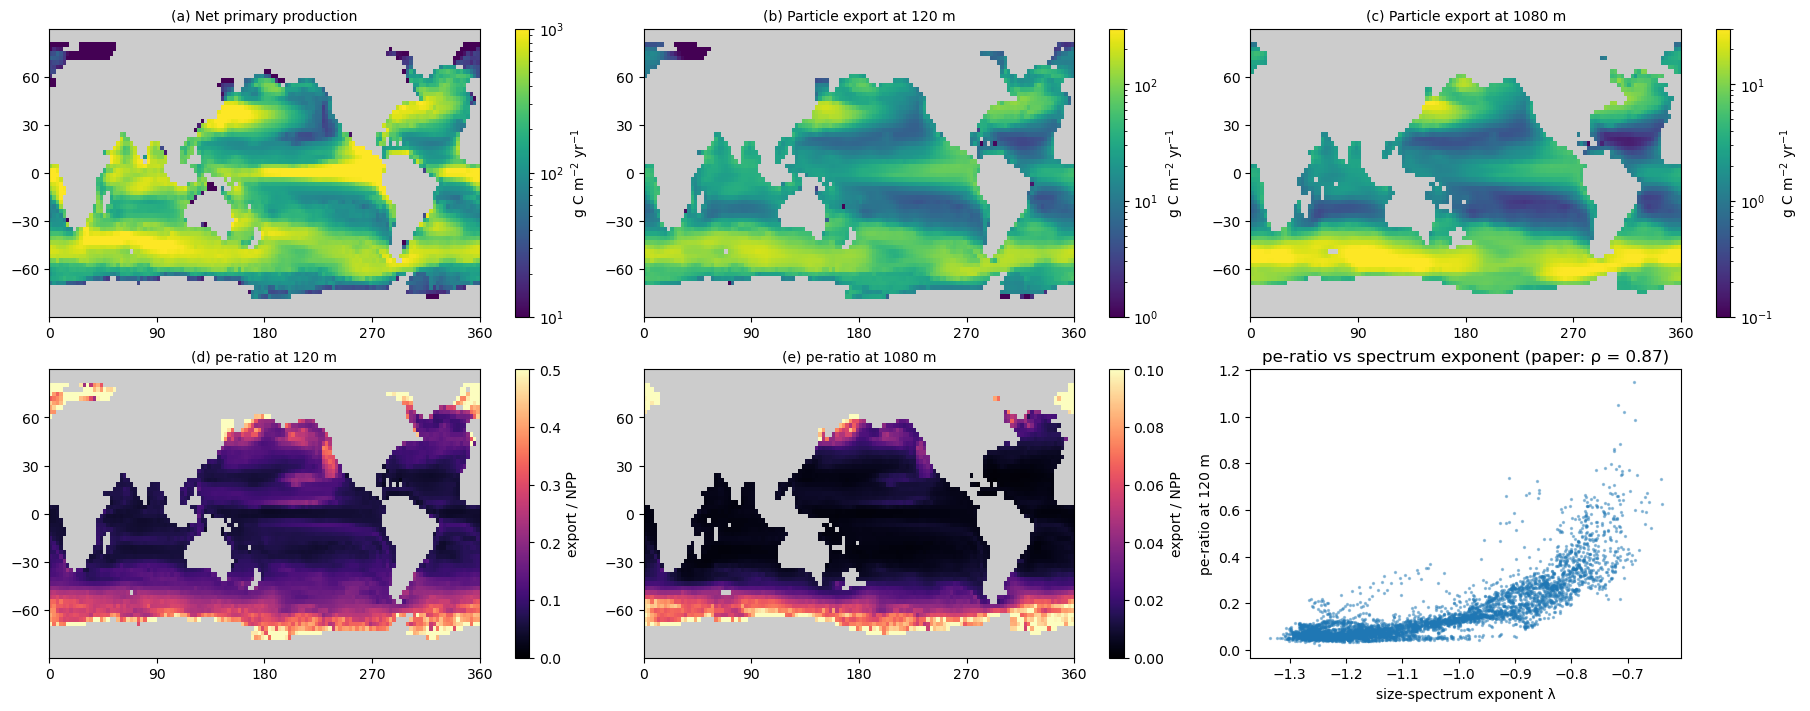

Spearman rank correlation, λ vs pe-ratio at 120 m: 0.83
Spearman rank correlation, λ vs pe-ratio at 1080 m: 0.85
(Serra-Pompei et al. 2022, Fig. 11: 0.87 at 120 m, 0.94 at 1080 m)


In [4]:
iP = np.where(ctype == "POM")[0][0]; v = vel[nN + iP]
NPPcol = integ(NPPy, np.ones_like(up)) / 1000                   # g C m^-2 yr^-1 (all layers)
def export_at(layer):                                            # g C m^-2 yr^-1 leaving the bottom of `layer`
    sel = iz == layer
    E = np.full((nx, ny), np.nan); E[ix[sel], iy[sel]] = v * B[sel, iP] * 365 / 1000; return E
E120, E1080 = export_at(1), export_at(6)
area = np.zeros((nx, ny)); sel0 = iz == 0; area[ix[sel0], iy[sel0]] = vol[sel0] / dz[0]
Pg = lambda F: np.nansum(F * area) / 1e15
print(f"global NPP {Pg(NPPcol):.1f} PgC/yr (observational estimates ~36-78, Carr et al. 2006); "
      f"export at 120 m {Pg(E120):.1f} PgC/yr, at 1080 m {Pg(E1080):.2f} PgC/yr; "
      f"global pe-ratio at 120 m {Pg(E120) / Pg(NPPcol):.2f}")
fig, axs = plt.subplots(2, 3, figsize=(18, 7), constrained_layout=True)
fig.colorbar(gmap(axs[0, 0], NPPcol, "(a) Net primary production", LogNorm(10, 1000)), ax=axs[0, 0], label="g C m$^{-2}$ yr$^{-1}$")
fig.colorbar(gmap(axs[0, 1], E120, "(b) Particle export at 120 m", LogNorm(1, 300)), ax=axs[0, 1], label="g C m$^{-2}$ yr$^{-1}$")
fig.colorbar(gmap(axs[0, 2], E1080, "(c) Particle export at 1080 m", LogNorm(0.1, 30)), ax=axs[0, 2], label="g C m$^{-2}$ yr$^{-1}$")
fig.colorbar(gmap(axs[1, 0], E120 / NPPcol, "(d) pe-ratio at 120 m", None, "magma", vmin=0, vmax=0.5), ax=axs[1, 0], label="export / NPP")
fig.colorbar(gmap(axs[1, 1], E1080 / NPPcol, "(e) pe-ratio at 1080 m", None, "magma", vmin=0, vmax=0.1), ax=axs[1, 1], label="export / NPP")
axs[1, 2].scatter(lam[ocean], (E120 / NPPcol)[ocean], s=2, alpha=0.4)
axs[1, 2].set(xlabel="size-spectrum exponent λ", ylabel="pe-ratio at 120 m", title="pe-ratio vs spectrum exponent (paper: ρ = 0.87)")
plt.show()
ok = ocean & np.isfinite(E120 / NPPcol)
rank = lambda a: np.argsort(np.argsort(a))
for lab, E in (("120 m", E120), ("1080 m", E1080)):
    pe = E / NPPcol; ok = ocean & np.isfinite(pe) & np.isfinite(lam)
    print(f"Spearman rank correlation, λ vs pe-ratio at {lab}: {np.corrcoef(rank(lam[ok]), rank(pe[ok]))[0, 1]:.2f}")
print("(Serra-Pompei et al. 2022, Fig. 11: 0.87 at 120 m, 0.94 at 1080 m)")

## 4. Seasonal community size spectra in the North Atlantic (cf. Serra-Pompei et al. 2022, Fig. 6)

Normalized community biomass spectrum in the surface layer at 50°N, 30°W for the four seasons
(three-month means of the final year's monthly snapshots), split into protists and copepods,
with the fitted exponent.

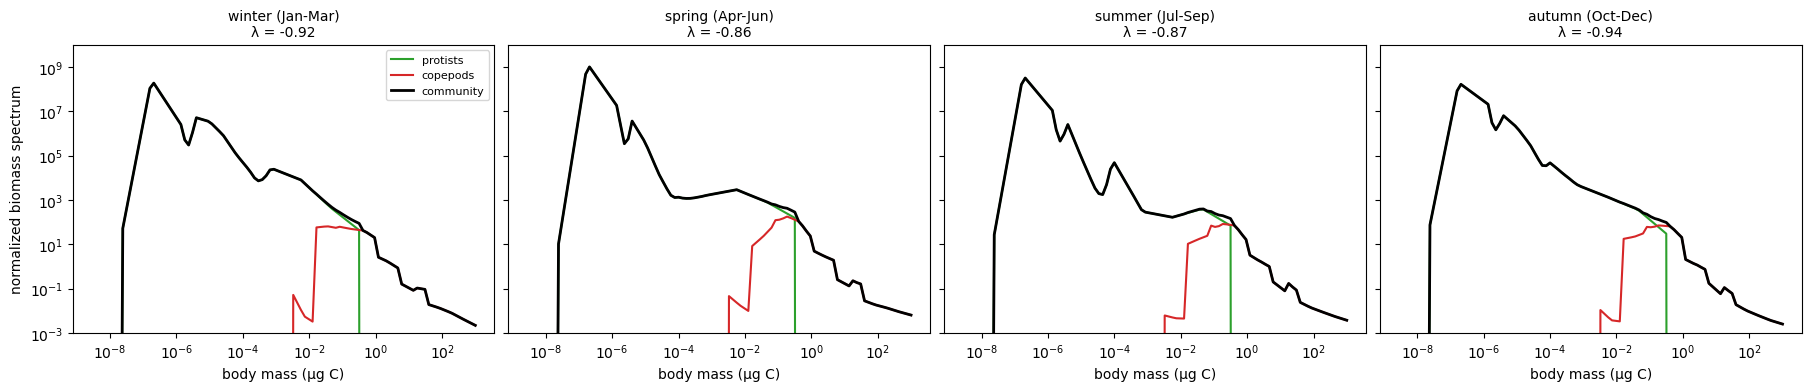

In [5]:
lon, lat = 330, 50
i0, j0 = np.argmin(abs(x - lon)), np.argmin(abs(y - lat))
b0 = np.where((ix == i0) & (iy == j0) & (iz == 0))[0][0]
seasons = {"winter (Jan-Mar)": [0, 1, 2], "spring (Apr-Jun)": [3, 4, 5], "summer (Jul-Sep)": [6, 7, 8], "autumn (Oct-Dec)": [9, 10, 11]}
fig, axs = plt.subplots(1, 4, figsize=(18, 3.8), sharey=True, constrained_layout=True)
for ax, (sname, mo) in zip(axs, seasons.items()):
    Bs = Umon[b0, nN:, mo].mean(axis=0) if Umon.shape[1] == Umean.shape[1] else Umon[mo, b0, nN:].mean(axis=0)
    tot = community_spectrum(Bs[None, :])[0]
    for label, sel, col in (("protists", prot, "tab:green"), ("copepods", cope, "tab:red")):
        ax.loglog(mc, community_spectrum(np.where(sel, Bs, 0)[None, :])[0], color=col, label=label)
    ax.loglog(mc, tot, "k", lw=2, label="community")
    lam0 = fit_exponent(tot)
    ax.set_title(f"{sname}\nλ = {lam0:.2f}", fontsize=10); ax.set_xlabel("body mass (µg C)"); ax.set_ylim(1e-3, 1e10)
axs[0].set_ylabel("normalized biomass spectrum"); axs[0].legend(fontsize=8)
plt.show()

## 5. Pico-, nano- and microphytoplankton, and nutrient drift

Left: dominant size class of unicellular biomass (0–120 m), using Fortran `getFunctions` ESD
limits 2 and 20 µm. Right: final-year surface nitrogen relative to the World Ocean Atlas field the
run started from (`N0.mat`), a check of the slow nutrient drift the paper mentions.

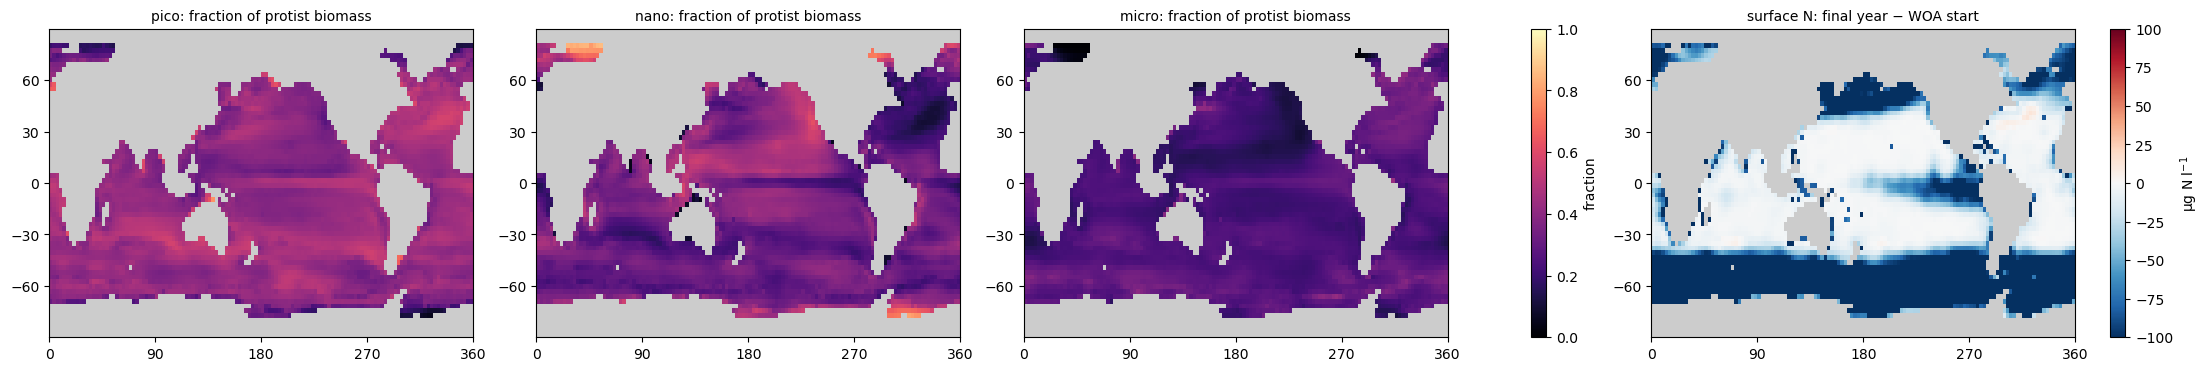

In [6]:
esd = 1e4 * 1.5 * (m * 1e-6) ** (1 / 3)
cls = {"pico": prot & (esd <= 2), "nano": prot & (esd > 2) & (esd <= 20), "micro": prot & (esd > 20)}
parts = np.stack([integ(B[:, s].sum(1)) for s in cls.values()], axis=-1)
frac = parts / parts.sum(-1, keepdims=True)
N0 = loadmat(ROOT / "NUMmodel/TMs/MITgcm_2.8deg/N0.mat")["N"][:, :, 0]
Nsurf = to_grid(Umean[:, 0])[:, :, 0]
fig, axs = plt.subplots(1, 4, figsize=(22, 3.6), constrained_layout=True)
for ax, (k, f) in zip(axs[:3], zip(cls, np.moveaxis(frac, -1, 0))):
    pc = gmap(ax, f, f"{k}: fraction of protist biomass", None, "magma", vmin=0, vmax=1)
fig.colorbar(pc, ax=axs[:3], label="fraction")
fig.colorbar(gmap(axs[3], Nsurf - N0, "surface N: final year − WOA start", None, "RdBu_r", vmin=-100, vmax=100), ax=axs[3], label="µg N l$^{-1}$")
plt.show()